# QFT Circuit - Transpilation Across Topologies

**Goal:** Build a 7-qubit Quantum Fourier Transform (QFT) circuit and compile it onto three physical qubit topologies.  
Track how **circuit depth**, **CX gate count**, and **SWAP overhead** change with topology and optimisation level.

---

### Background

When we design a quantum algorithm, we write it as a *logical circuit*: a sequence of gates acting on abstract qubits, assuming any qubit can interact with any other. Real quantum hardware does not work that way. Physical qubits are wired together in a fixed **coupling map**: only adjacent qubits can participate in a two-qubit gate. When the logical circuit requires a gate between two qubits that are not neighbours, the compiler must *route* that interaction by inserting additional **SWAP gates** to shuttle qubit states along the coupling map until the two relevant qubits are adjacent.

Each SWAP gate decomposes into three CX (CNOT) gates, and CX gates are the noisiest operations on superconducting hardware. Routing overhead therefore translates directly into lower fidelity. Understanding how coupling-map topology drives this overhead is essential for choosing hardware, designing algorithms, and evaluating compiler quality.

The **Quantum Fourier Transform** is an ideal stress-test for this analysis because it requires gates between *every* pair of qubits (O(n²) two-qubit interactions for n qubits), making it maximally sensitive to connectivity restrictions.

## 1. Setup

We import four helper modules that keep the notebook clean:

- **`circuits.py`** — builds the logical QFT circuit using Qiskit primitives
- **`topologies.py`** — defines the three physical coupling maps we will test
- **`transpiler.py`** — wraps Qiskit's `transpile()` call and extracts cost metrics (depth, CX count, estimated SWAP overhead)
- **`plotting.py`** — all visualisation helpers

Setting `N_QUBITS = 7` gives us enough qubits to make routing decisions non-trivial while keeping runtimes fast.

In [1]:
# Install dependencies (run once)
# %pip install qiskit qiskit-aer matplotlib numpy

In [2]:
import sys, os
sys.path.insert(0, os.path.dirname(os.path.abspath(".")))

import warnings
warnings.filterwarnings("ignore")

# Helper modules (circuits.py / topologies.py / transpiler.py / plotting.py)
from circuits   import build_qft
from topologies import get_topologies
from transpiler import run_transpilation, print_report, BASIS_GATES, OPT_LEVELS
from plotting   import (
    plot_logical_circuit,
    plot_topologies,
    plot_opt3_bars,
    plot_depth_vs_opt,
    plot_cx_by_opt,
    plot_cx_u_tradeoff,
    plot_heatmap,
)

import matplotlib
matplotlib.use("inline")
import matplotlib.pyplot as plt

N_QUBITS = 7

print(f"Qiskit ready  |  {N_QUBITS}-qubit QFT  |  basis: {BASIS_GATES}")

Qiskit ready  |  7-qubit QFT  |  basis: ['cx', 'u']


## 2. Logical QFT Circuit

The **Quantum Fourier Transform (QFT)** maps computational-basis amplitudes into the phase/frequency basis:

$$|x\rangle \mapsto \frac{1}{\sqrt{2^n}} \sum_{y=0}^{2^n-1} e^{2\pi ixy/2^n}|y\rangle$$

Construction: Hadamards plus controlled phase rotations between many qubit pairs, followed by optional output-order swaps.

### Gate structure

### Gate structure

The standard QFT circuit consists of two main components:

1. **Hadamard and controlled-phase rotations.** Each qubit is first acted on by a Hadamard gate and then receives controlled-phase rotations from all higher-index qubits. The rotation angle decreases with the distance between the qubits, following $(CP(\pi/2^k))$. These controlled rotations encode the phases that define the Fourier basis. Since every pair of qubits interacts exactly once, an (n)-qubit QFT contains $\frac{n(n-1)}{2}$ two-qubit gates.

2. **SWAP reversal.** The standard QFT produces its output in reversed bit order. A sequence of $(\lfloor n/2 \rfloor)$ SWAP gates restores the usual ordering. These SWAP gates are part of the algorithm itself, although during transpilation they may be merged with routing SWAPs introduced to satisfy the hardware connectivity.

The QFT therefore places a high demand on qubit connectivity. Because controlled-phase gates are required between every pair of qubits, any missing connection in the hardware coupling map must be compensated for by additional routing operations.

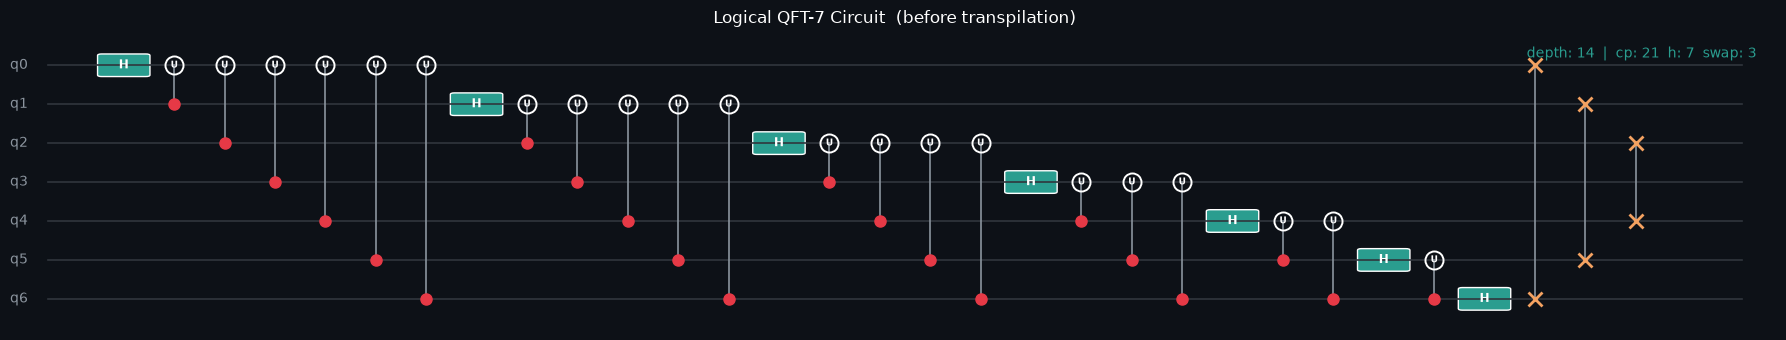

In [3]:
logical = build_qft(N_QUBITS)
fig = plot_logical_circuit(N_QUBITS, logical)
plt.show()

## 3. Physical Qubit Topologies

We test three coupling maps that represent distinct classes of real hardware.

| Topology | Connectivity
|---|---|
| **Linear Chain** | 1-D nearest-neighbour
| **Heavy-Hex** | Sparse hexagonal lattice
| **Full Graph** | All-to-all

### Why these three?

They span the space of practically relevant connectivity classes, from worst to best:

**Linear Chain** is the hardest case. Each qubit is connected only to its immediate neighbours, so the maximum routing distance between any two qubits is `n − 1` hops. For the QFT, which needs gates between qubit 0 and qubit 6, this means up to 6 SWAPs just to bring them adjacent.

**Heavy-Hex** is IBM's current production qubit connectivity topology, adopted across its quantum processors since 2021. It employs a sparse connectivity graph that intentionally limits the number of nearest-neighbor interactions, reducing frequency collisions and crosstalk while improving two-qubit gate fidelity. Although the lower connectivity introduces additional routing overhead, this cost is largely mitigated by the optimizations implemented in IBM's compiler and Qiskit's transpiler.

**Full Graph** is the theoretical ideal. Every qubit directly connected to every other. No routing is ever needed, the compiler only has to decompose the logical gates into the basis set. This gives us a lower bound on circuit cost that no real hardware can beat. It also tells us how much of the compiled circuit's cost is intrinsic to the QFT itself versus imposed by topology.

In [4]:
topologies = get_topologies(N_QUBITS)

for name, t in topologies.items():
    cmap = t["map"]
    edges = len(list(cmap.get_edges())) // 2
    avg_degree = (2 * edges) / cmap.size()
    print(f"{t['short']:<15}  qubits={f'{cmap.size()}':<5}  edges={f'{edges}':<5}  avg_degree={f'{avg_degree:.2f}':<5}")

Linear           qubits=7      edges=6      avg_degree=1.71 
Heavy-Hex        qubits=19     edges=20     avg_degree=2.11 
Full Graph       qubits=7      edges=21     avg_degree=6.00 


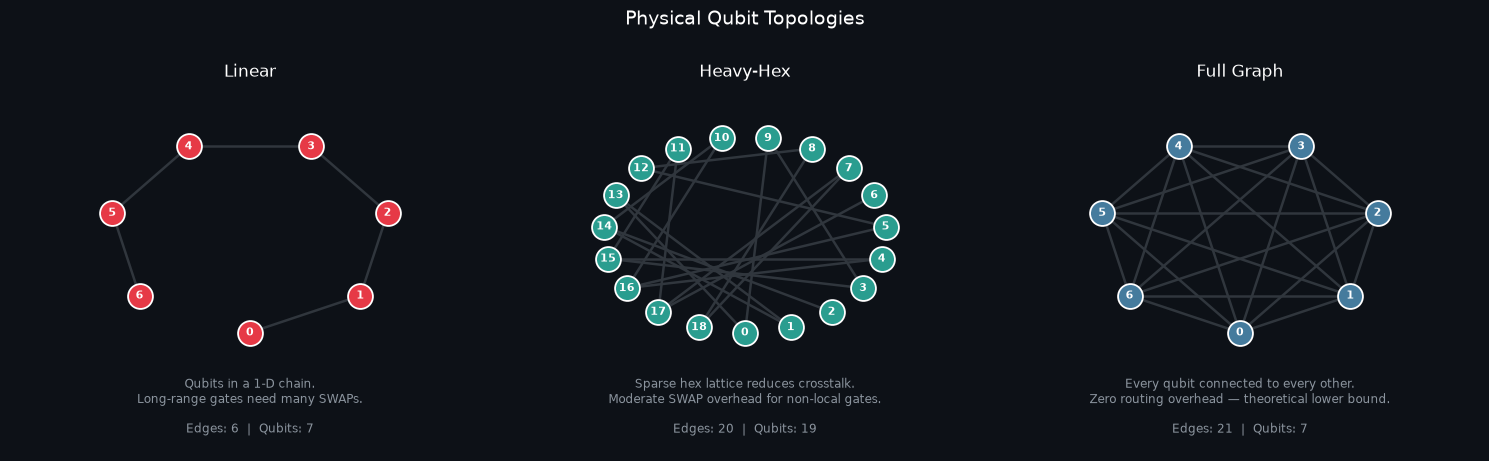

In [5]:
fig = plot_topologies(topologies)
plt.show()

## 4. Transpilation

`qiskit.transpile()` converts a hardware-independent quantum circuit into one that satisfies
the constraints of a target backend. The transpiler performs six stages:

1. **Init** – prepares the circuit and configures the transpilation process.
2. **Layout** – assigns logical qubits to physical qubits.
3. **Routing** – inserts additional operations when required by the hardware connectivity.
4. **Translation** – rewrites the circuit using the backend's native gate set.
5. **Optimization** – simplifies the circuit while preserving its functionality.
6. **Scheduling** – optionally schedules instructions in time according to the backend timing constraints.


### What each stage does

**Init** prepares the transpilation process by collecting information about the target backend and the input circuit. During this stage, Qiskit validates the circuit, builds the target description (including the native gate set and coupling map), and configures the sequence of transpiler passes that will be executed. The circuit itself is generally unchanged.

**Layout** assigns the circuit's logical qubits to physical qubits on the target device. Since different physical qubits may have different connectivity and calibration properties, choosing a good layout is essential for reducing the number of additional operations required later.

**Routing** ensures that every multi-qubit operation satisfies the connectivity constraints of the target hardware. Whenever two qubits involved in a gate are not directly connected according to the coupling map, the transpiler inserts SWAP operations to move the quantum states until the interaction becomes executable.

**Translation** rewrites the routed circuit using only the native instruction set supported by the target backend. High-level gates are decomposed into equivalent sequences of basis gates defined by the backend's target, ensuring that every operation can be executed by the hardware.

**Optimization** applies a sequence of transformations that simplify the translated circuit without changing its functionality. These include cancelling redundant gates, combining consecutive single-qubit rotations, eliminating identity operations, and, at higher optimization levels, performing more advanced circuit resynthesis to reduce gate count and circuit depth.
* `optimization_level=0` performs only the transformations required to produce a valid circuit for the target hardware, without attempting to reduce circuit size or depth.
* `optimization_level=1` applies lightweight optimizations, such as cancelling redundant gates, combining adjacent single-qubit gates, and selecting improved layouts and routing strategies.
* `optimization_level=2` performs more aggressive optimizations, including additional gate cancellation based on commutation rules, together with more extensive layout and routing improvements.
* `optimization_level=3` applies the most advanced optimization passes. It can resynthesize blocks of multi-qubit operations into more efficient equivalent circuits and then perform further simplification passes to reduce gate count and circuit depth whenever possible.


### The metrics we track

- **Circuit depth**: the length of the longest path through the circuit, measured in gate layers. This is proportional to execution time.
- **CX count**: total number of CNOT gates. This is the primary noise budget: each CX has error rates of 0.1–1% on current hardware, versus ~0.01–0.1% for single-qubit gates.
- **SWAP estimate**: we estimate the number of routing SWAPs as `(CX_transpiled − CX_baseline) // 3`, where `CX_baseline` is the CX count of the topology-free basis decomposition. Each SWAP costs exactly 3 CX gates, so this gives the number of logical SWAPs the router inserted.

In [6]:
results = run_transpilation(logical, topologies)
print_report(logical, topologies, results)

  QFT-7 Transpilation Report  |  basis: ['cx', 'u']

Logical circuit  →  depth=14  cp=21  h=7  swap=3
Topology-free basis decomposition  →  cx=51

Topology   Opt   Depth     CX      U   SWAP≈   Total
----------------------------------------------------
Linear       0     104    126     70      25     196
Linear       1     109    120     70      23     190
Linear       2      81     75    101       8     176
Linear       3      81     75    101       8     176

Heavy-Hex    0     123    186     70      45     256
Heavy-Hex    1     113    102     70      17     172
Heavy-Hex    2      92     70     86       6     156
Heavy-Hex    3      92     70     86       6     156

Full Graph   0      48     51     70       0     121
Full Graph   1      48     51     70       0     121
Full Graph   2      45     42     70       0     112
Full Graph   3      45     42     70       0     112



## 5. Results — Opt-0 vs Opt-3 Snapshot

The bars below compare the naive compiled cost (Opt-0, lighter bars) against the best achievable cost (Opt-3, solid bars) for each topology. This gives an immediate sense of two things: how much the compiler can improve over a naive compilation, and how much the topology itself constrains the result regardless of optimisation effort.

### What to look for

**Gap between Opt-0 and Opt-3.** A large gap means the compiler is doing a lot of work — primarily finding better layouts and cancelling redundant SWAPs. A small gap means the circuit is already near-optimal after basic decomposition, or that the topology leaves little room for improvement.

**Gap between topologies at Opt-3.** This is the irreducible cost of connectivity. Even with the best compiler, a Linear Chain will require more CX gates than a Full Graph for the QFT, because some long-range interactions simply cannot be avoided. The difference between Heavy-Hex and Full Graph at Opt-3 tells you the practical cost of running QFT-based algorithms on IBM's current hardware versus an ideal device.

**SWAP overhead.** Watch how the SWAP estimate changes across topologies. The Full Graph should show zero or near-zero estimated SWAPs (any non-zero value comes from the measurement of extra CX against a slightly different baseline). Linear Chain will show the largest SWAP count, quantifying exactly how expensive routing is on 1-D hardware.

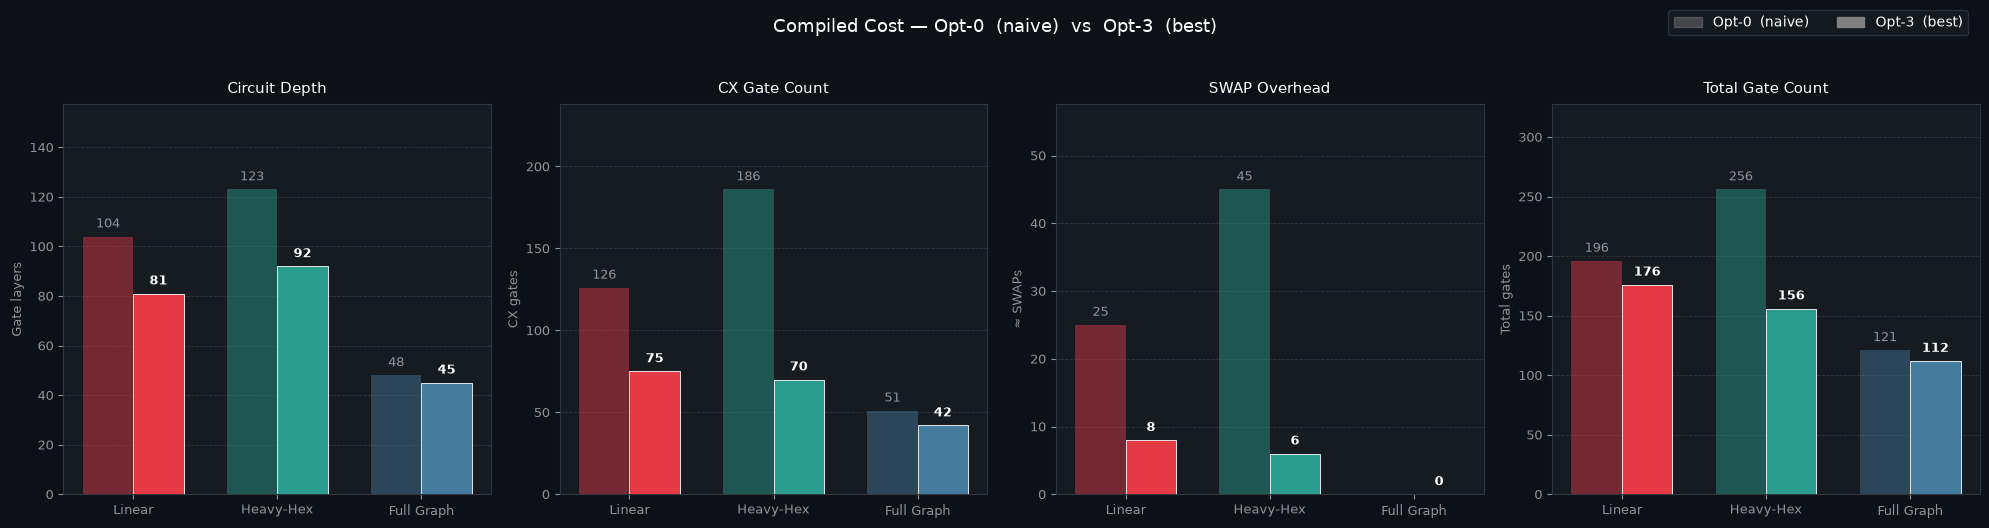

In [7]:
fig = plot_opt3_bars(topologies, results)
plt.show()

## 6. Depth vs Optimisation Level

QFT contains controlled phase rotations between many qubit pairs. On sparse coupling maps, the transpiler must choose a layout and route non-local interactions with additional CX gates. The line plot shows how much the optimisation passes reduce that cost.

### Reading the plot

Each line represents one topology; the x-axis steps through the four optimisation levels and the y-axis shows circuit depth after compilation.

Slope of each line reflects how much the compiler improves with more effort. Flattening between Opt-2 and Opt-3 suggests that the compiler is approaching the limit of what's achievable with its heuristics.

Vertical separation between lines at any given optimisation level reflects the topology penalty.

### The depth is not always improved

Although higher optimization levels generally spend more effort reducing the circuit, they do not guarantee a monotonic improvement in depth. 

In our linear topology, level 1 produces a slightly deeper circuit than level 0. 

Different optimization levels use different pass pipelines, and the objective is not always to minimize depth alone.

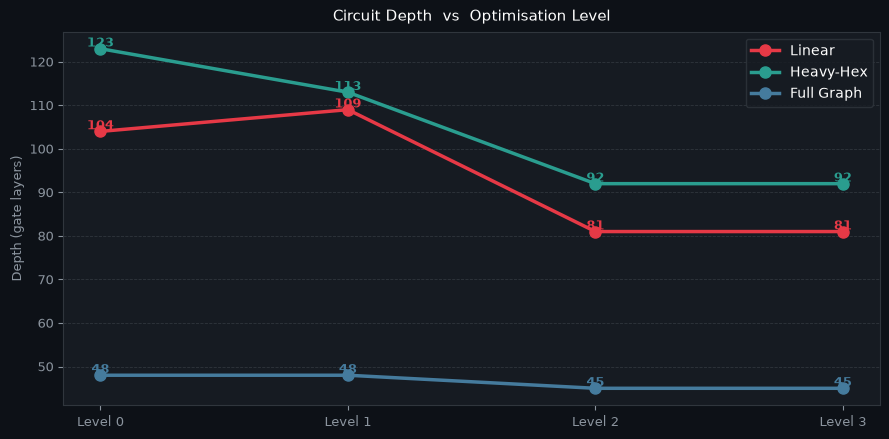

In [8]:
fig = plot_depth_vs_opt(topologies, results)
plt.show()

## 7. CX Gate Count

The number of **CX gates** is one of the best indicators of how reliable a quantum circuit will be on current hardware, since two-qubit gates are much noisier than single-qubit gates.

### Why CX count matters

On today's superconducting quantum computers, CX gates are the main source of errors. Every additional CX gate slightly increases the probability that the computation will fail. For this reason, reducing the number of CX gates is one of the primary goals of the transpiler, often having a greater impact on circuit fidelity than reducing depth alone.

### Reading the grouped bars

Each group of bars corresponds to one optimisation level, while the three bars within each group represent the different hardware topologies.

The chart allows us to compare:

* **Within each optimisation level:** how the hardware topology affects the number of CX gates. Large differences indicate that connectivity has a strong impact on the transpiled circuit.
* **Across optimisation levels:** how effectively the transpiler reduces the number of CX gates. Since a Full Graph requires no routing, its CX count is expected to change very little, whereas the Linear Chain should benefit the most from higher optimisation levels.


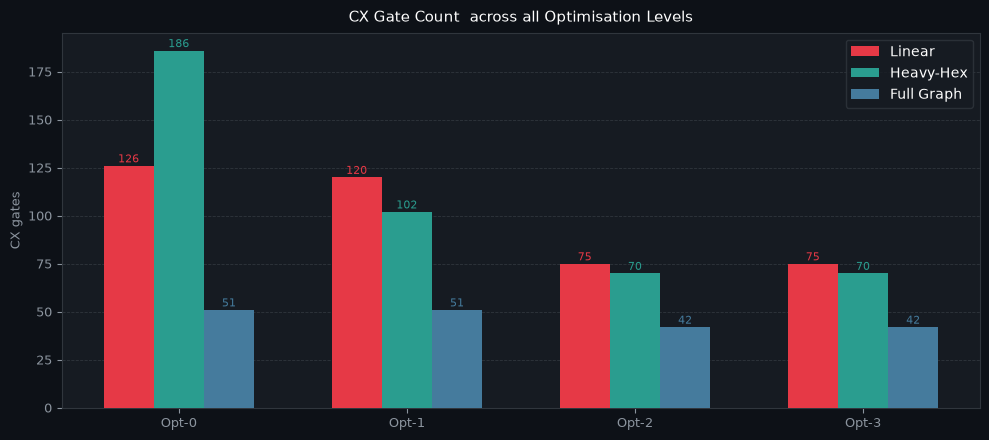

In [9]:
fig = plot_cx_by_opt(topologies, results)
plt.show()

## 8. U Gates Analysis

Sometimes the number of single-qubit `U` gates increases while the number of `CX` gates decreases. This is not a mistake, it is one of the main optimization trade-offs.

The transpiler works by rewriting the circuit into an equivalent circuit for the chosen basis and coupling map. 
In our basis, `U` represents a general single-qubit rotation, while `CX` is the two-qubit entangling gate. 
On current superconducting devices, two-qubit gates are typically much noisier and slower than single-qubit gates, so replacing several `CX` gates with extra single-qubit rotations can still improve the final circuit.

The important idea is therefore not "fewer gates is always better", but "fewer noisy two-qubit gates can be worth several additional single-qubit rotations".

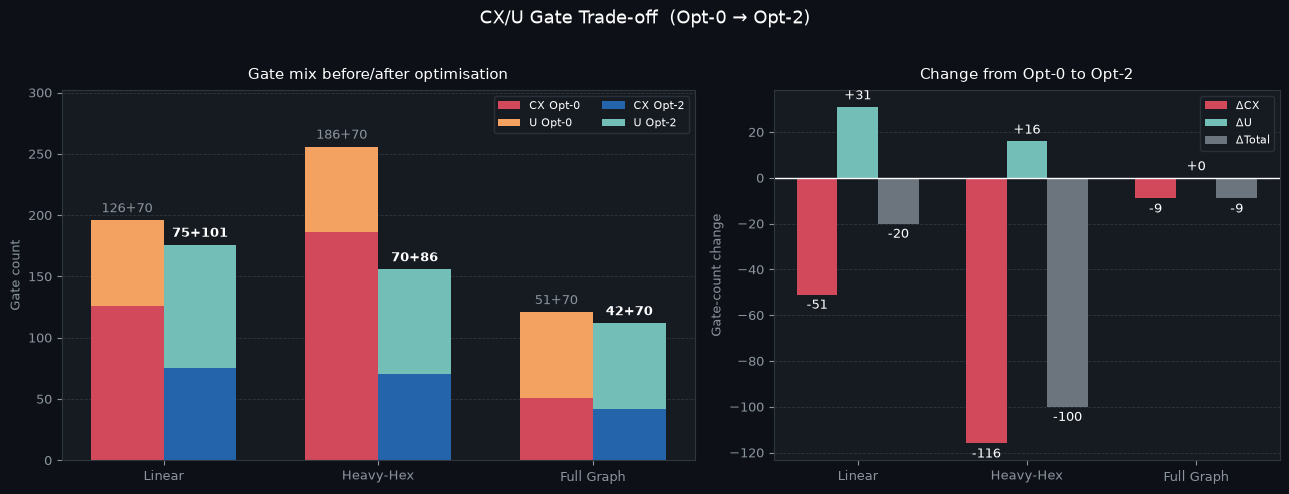

In [10]:
fig = plot_cx_u_tradeoff(topologies, results, compare_opts=(0, 2))
plt.show()

## 9. Summary Heatmap (All Optimisation Levels)

Each cell shows the **raw value**; colour encodes relative cost column-by-column  
(green = cheapest, red = most expensive).

### How to read the heatmap

Rows are `topology / optimisation level` pairs — twelve rows in total (3 topologies × 4 optimisation levels). Columns are the five metrics we track. Colour is normalised *within each column*, so green always means cheapest on that metric and red means most expensive, regardless of absolute scale.

**Horizontal bands** (groups of four rows per topology) reveal the optimisation trajectory: do rows get greener as you go from Opt-0 to Opt-3? If so, the compiler is effective for that topology. If the colour barely changes across the four rows, the compiler has little room to manoeuvre — likely because the topology itself leaves few routing choices.

**Vertical patterns** reveal which metrics are most sensitive to topology. The CX and SWAP columns typically show the widest colour variation, because they directly reflect routing overhead. The U-gates column often shows less variation, because single-qubit gate count is driven more by the circuit's intrinsic gate structure than by routing.

**Reading the numbers.** Because colour is column-normalised, a green cell with a large number and a red cell with a small number can coexist — what matters is the relative ordering within that metric. For absolute comparisons across metrics, read the printed values.

### A comment about U gates
The increase in U gates at higher optimization levels is not an error.
It is the result of a trade-off performed by the transpiler.

The increase in single-qubit U gates at higher optimization levels is an expected consequence of Qiskit's resynthesis passes. 
The transpiler rewrites blocks of operations into equivalent circuits with fewer two-qubit gates, often at the cost of introducing additional single-qubit rotations. 
Since single-qubit gates are significantly less error-prone than CX gates, this trade-off generally improves the quality of the transpiled circuit.

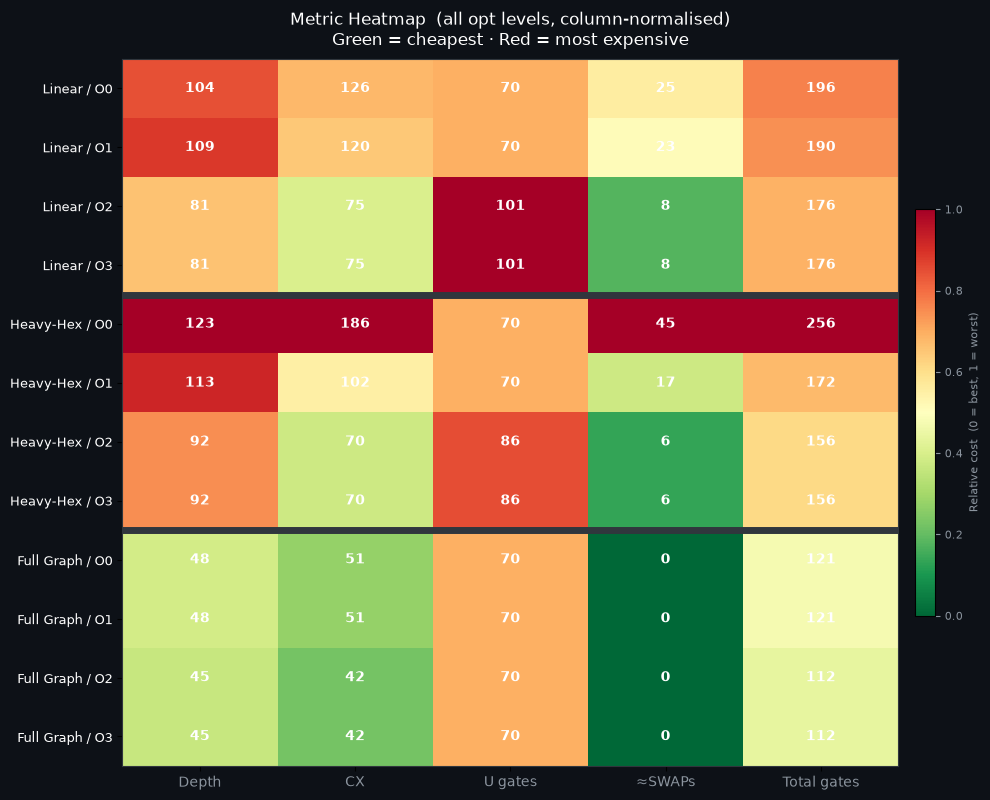

In [11]:
fig = plot_heatmap(topologies, results)
plt.show()

## 10. Analysis & Conclusions

This project analysed how hardware connectivity influences the compilation of a Quantum Fourier
Transform (QFT) circuit. Although the logical circuit is identical in every case, the
physical topology has a significant impact on the compiled result.

The **Full Graph** consistently produces the smallest circuit depth and requires no routing,
since every qubit can directly interact with every other qubit. It therefore represents an
ideal reference, but one that is impractical for large superconducting quantum processors
because fully connecting all qubits is difficult to engineer.

The **Linear Chain** represents the opposite extreme. Limited nearest-neighbour connectivity
forces the transpiler to insert many SWAP operations, increasing both circuit depth and the
number of two-qubit gates. This additional routing makes the compiled circuit considerably
more expensive.

The **Heavy-Hex** topology provides a compromise between these two extremes. Although routing
is still required, its connectivity is sufficient for the transpiler to find significantly
more efficient layouts than in a simple linear chain, while remaining realistic for current
IBM quantum hardware.

The comparison across optimisation levels also highlights the importance of compilation.
Moving from optimisation level 0 to level 3 substantially reduces circuit depth and CX gate
count, especially on sparse topologies. The largest improvements come from routing
optimisations, gate cancellation, and circuit resynthesis, which sometimes replace several
single-qubit gates in order to eliminate expensive two-qubit operations.

Overall, the experiments demonstrate that quantum algorithm performance depends not only on
the algorithm itself but also on the interaction between hardware topology and compiler
optimisations. Efficient transpilation is therefore essential for executing quantum circuits
reliably on today's noisy quantum devices.